This code evalutates the efficiency of the scintillator detector. 

This code evalutates the efficiency of the scintillator detector. 

In [100]:
import matplotlib.pyplot as plt # https://matplotlib.org/
import numpy as np # http://www.numpy.org/
import tekwfm
import os
from scipy import integrate
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import moyal as moyal_dist

In [101]:
#import files - 
doVerbose = False

#import the wfm file
# top and bottom layers in coincidence
#df_top_2 = pd.read_csv('3_layer_hair_gel/efficiency_3/050326_3layereff_1900_5000_6_ch2_proc.csv', index_col=0)
#df_bottom_2 = pd.read_csv('3_layer_hair_gel/efficiency_3/050326_3layereff_1900_5000_6_ch1_proc.csv', index_col=0)
#df_middle_2 = pd.read_csv('3_layer_hair_gel/efficiency_3/050326_3layereff_1900_5000_6_ch3_proc.csv', index_col=0)

df_top_2 = pd.read_csv('3_layer_hair_gel/efficiency_2/020326_3layereff_1900_5000_2_ch3_proc.csv', index_col=0)
df_bottom_2 = pd.read_csv('3_layer_hair_gel/efficiency_2/020326_3layereff_1900_5000_2_ch1_proc.csv', index_col=0)
df_middle_2 = pd.read_csv('3_layer_hair_gel/efficiency_2/020326_3layereff_1900_5000_2_ch2_proc.csv', index_col=0)

datasets= {
    "top_2": df_top_2,
    "bottom_2": df_bottom_2,
    "middle_2": df_middle_2
}

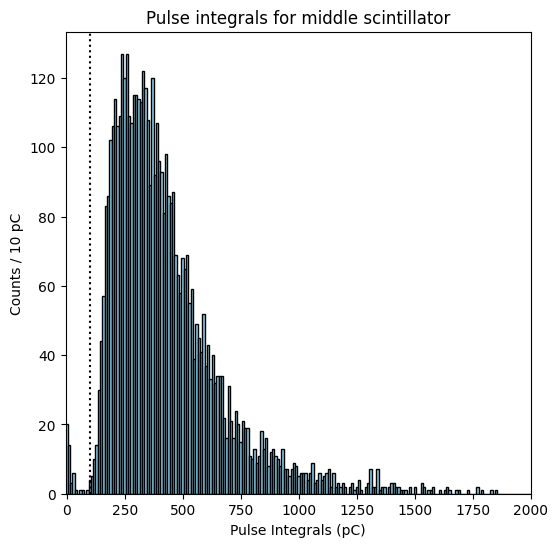

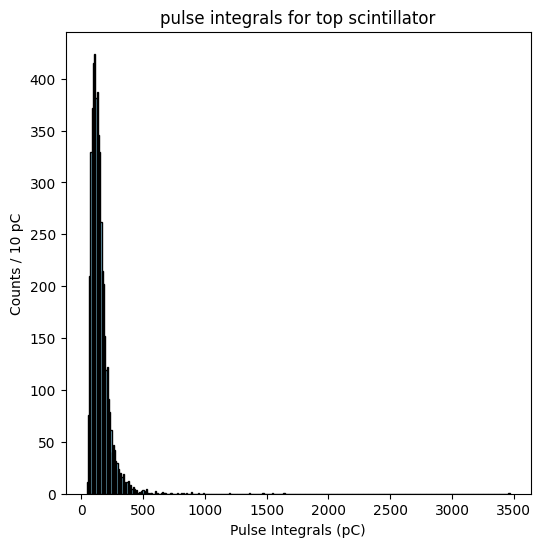

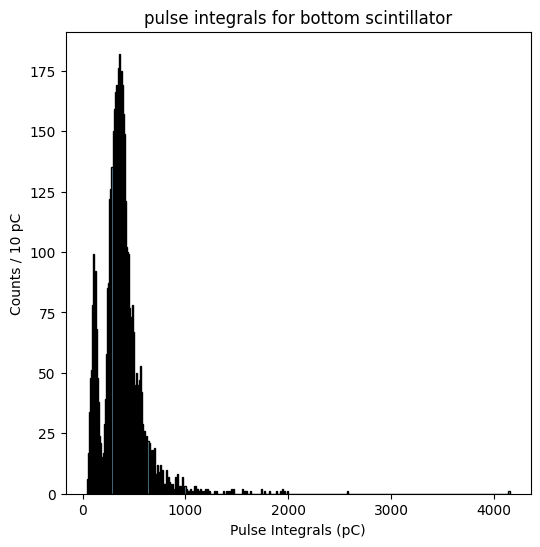

5000
4949
0.9898
0.0014209827585160903


In [102]:
# define detection threshold for channel 2
# plot histogram of integrals for channel 2
integrals_mid = df_middle_2['integral_pC']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(integrals_mid)-np.min(integrals_mid))/10) #chosen 1 bin = 10 pC
plt.hist(integrals_mid, bins=int_number_of_bins, color='skyblue', edgecolor='black')
plt.xlim(-5, 2000)
#plt.ylim(0,1500)
plt.axvline(100, linestyle=':', color='black')
plt.title('Pulse integrals for middle scintillator')
plt.xlabel('Pulse Integrals (pC)')
plt.ylabel('Counts / 10 pC')
plt.show()

integrals_top = df_top_2['integral_pC']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(integrals_top)-np.min(integrals_top))/10) #chosen 1 bin = 10 pC
plt.hist(integrals_top, bins=int_number_of_bins, color='skyblue', edgecolor='black')
#plt.xlim(-5, 2500)
#plt.ylim(0,1500)
plt.title('pulse integrals for top scintillator')
plt.xlabel('Pulse Integrals (pC)')
plt.ylabel('Counts / 10 pC')
plt.show()

integrals_bottom = df_bottom_2['integral_pC']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(integrals_bottom)-np.min(integrals_bottom))/10) #chosen 1 bin = 10 pC
plt.hist(integrals_bottom, bins=int_number_of_bins, color='skyblue', edgecolor='black')
#plt.xlim(0, 1500)
#plt.ylim(0,1500)
plt.title('pulse integrals for bottom scintillator')
plt.xlabel('Pulse Integrals (pC)')
plt.ylabel('Counts / 10 pC')
plt.show()

"""
amplitudes_mid = df_middle_2['amplitude']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(amplitudes_mid)-np.min(amplitudes_mid))/(10e-3)) #chosen 1 bin = 10 pC
plt.hist(amplitudes_mid, bins=int_number_of_bins, color='skyblue', edgecolor='black')
#plt.xlim(-5, 2500)
#plt.ylim(0,1500)
plt.axvline(0.3, linestyle=':', color='black')
plt.title('Pulse amplitudes for middle scintillator')
plt.xlabel('Pulse amplitudes (V)')
plt.ylabel('Counts / 100 mV')
plt.show()

amplitudes_top = df_top_2['amplitude']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(amplitudes_top)-np.min(amplitudes_top))/(10e-3)) #chosen 1 bin = 10 pC
plt.hist(amplitudes_top, bins=int_number_of_bins, color='skyblue', edgecolor='black')
#plt.xlim(-5, 2500)
#plt.ylim(0,1500)
plt.axvline(0.3, linestyle=':', color='black')
plt.title('Pulse amplitudes for top scintillator')
plt.xlabel('Pulse amplitudes (V)')
plt.ylabel('Counts / 100 mV')
plt.show()

amplitudes_bottom = df_bottom_2['amplitude']
plt.figure(figsize=(6, 6))
int_number_of_bins = int((np.max(amplitudes_bottom)-np.min(amplitudes_bottom))/(10e-3)) #chosen 1 bin = 10 pC
plt.hist(amplitudes_bottom, bins=int_number_of_bins, color='skyblue', edgecolor='black')
#plt.xlim(-5, 2500)
#plt.ylim(0,1500)
plt.axvline(0.3, linestyle=':', color='black')
plt.title('Pulse amplitudes for bottom scintillator')
plt.xlabel('Pulse amplitudes (V)')
plt.ylabel('Counts / 100 mV')
plt.show()
"""

threshold_int = 100
ch2_column = 'integral_pC'
n_gate = len(df_middle_2)
n_hits = len(df_middle_2[df_middle_2[ch2_column].abs() > threshold_int])

efficiency = n_hits / n_gate
uncertainty = np.sqrt((efficiency * (1 - efficiency)) / n_gate)

print(n_gate)
print(n_hits)
print(efficiency)
print(uncertainty)

# need to not filter the data before the efficiency calculation!!!!

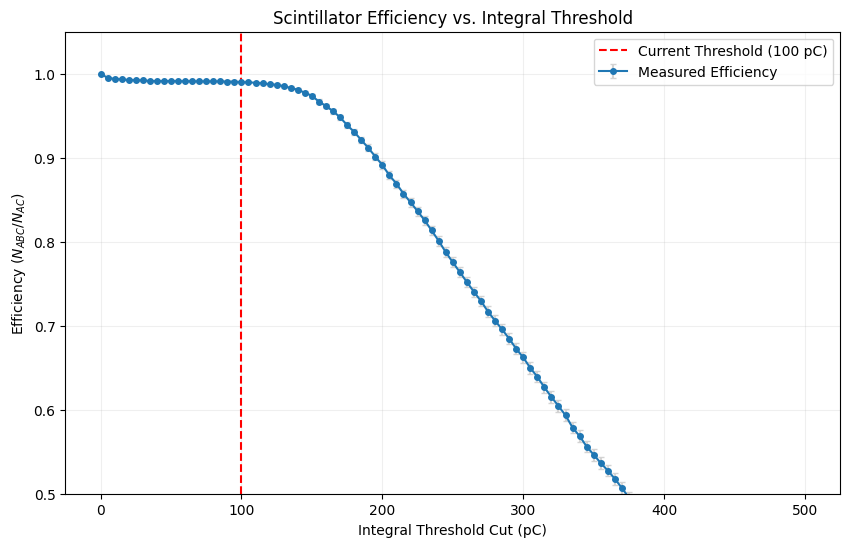

In [103]:
# 1. Define the range of thresholds to test
# We'll go from 0 to 1000 pC in steps of 10
test_thresholds = np.arange(0, 501, 5)

eff_list = []
unc_list = []

# Using your existing dataframe and column
integrals_abs = df_middle_2['integral_pC'].abs()
n_gate = len(df_middle_2)

# 2. Loop to calculate efficiency at each threshold
for t in test_thresholds:
    n_hits = len(df_middle_2[integrals_abs > t])
    
    epsilon = n_hits / n_gate
    # Binomial uncertainty
    sigma = np.sqrt((epsilon * (1 - epsilon)) / n_gate) if n_gate > 0 else 0
    
    eff_list.append(epsilon)
    unc_list.append(sigma)

# 3. Create the Plot
plt.figure(figsize=(10, 6))
plt.errorbar(test_thresholds, eff_list, yerr=unc_list, fmt='o', markersize=4, 
             linestyle='-', color='tab:blue', ecolor='lightgray', capsize=2, label='Measured Efficiency')

# Add a vertical line for the threshold you currently use (100 pC)
plt.axvline(threshold_int, color='red', linestyle='--', label=f'Current Threshold ({threshold_int} pC)')

plt.title('Scintillator Efficiency vs. Integral Threshold')
plt.xlabel('Integral Threshold Cut (pC)')
plt.ylabel('Efficiency ($N_{ABC} / N_{AC}$)')
plt.ylim(0.5, 1.05)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()